### Logistic Regression Analysis for Geomagnetic Storm Predictor on Time-Binned Dataset

In [3]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler          
from sklearn.linear_model import LogisticRegression           
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
)

In [4]:
df = pd.read_csv("../data/time_binned_dataset.csv", index_col=0, parse_dates=True)
df = df.sort_index()
print(df.shape)
print(df.index.min(), "->", df.index.max())

(87649, 57)
1995-01-01 00:00:00 -> 2024-12-30 00:00:00


In [6]:
HORIZON = 3
target_cols = [f"ap_target_{h}h" for h in (3, 6, 12, 24)] + \
              [f"storm_{h}h"     for h in (3, 6, 12, 24)]

TARGET_COL = f"storm_{HORIZON}h"

X = df.drop(columns=target_cols)    
y = df[TARGET_COL]

print("Features:", X.shape[1], "| storm rate:", round(y.mean()*100, 2), "%")

Features: 49 | storm rate: 1.83 %


In [10]:
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train: ", X_train.index.min(), "->", X_train.index.max())
print("Test: ", X_test.index.min(), "->", X_test.index.max())
print("Train storm %:", round(y_train.mean()*100, 2),
      "| Test storm %:", round(y_test.mean()*100, 2))

Train:  1995-01-01 00:00:00 -> 2018-12-30 18:00:00
Test:  2018-12-30 21:00:00 -> 2024-12-30 00:00:00
Train storm %: 2.0 | Test storm %: 1.16


In [14]:
logrep_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight = "balanced",
        max_iter = 1000,
        random_state = 42,
    )),
])

logrep_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](49,)","['bz_gsm_nt_mean','bz_gsm_nt_min','bz_gsm_nt_max',...,'ap_trend', 'ap_27d_ago','speed_27d_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,49
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_val

In [17]:
y_pred = logrep_pipe.predict(X_test)
y_pred_prob = logrep_pipe.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print(f"ROC-AUC : {roc_auc: .3f}")
print(f"PR-AUC : {pr_auc: .3f} (no-skill baseline = {y_test.mean():.3f})")
print(classification_report(y_test, y_pred, target_names=['No storm', 'Storm']))
print(confusion_matrix(y_test, y_pred))

ROC-AUC :  0.973
PR-AUC :  0.570 (no-skill baseline = 0.012)
              precision    recall  f1-score   support

    No storm       1.00      0.95      0.97     17327
       Storm       0.16      0.86      0.28       203

    accuracy                           0.95     17530
   macro avg       0.58      0.91      0.62     17530
weighted avg       0.99      0.95      0.96     17530

[[16434   893]
 [   28   175]]


In [19]:
coefs = pd.Series(
    logrep_pipe.named_steps["clf"].coef_[0],
    index=X.columns,
).sort_values()

print(coefs.tail(10))
print(coefs.head(10))

ap_max                     0.134445
flow_pressure_npa_min      0.138000
ap_mean                    0.158822
cme_max_half_angle_72h     0.236396
flow_speed_kms_mean        0.274815
flow_pressure_npa_last     0.291086
coupling_mean              0.332611
flow_speed_kms_last        0.615612
ap_now                     1.045403
b_magnitude_avg_nt_last    1.143667
dtype: float64
flow_speed_kms_min        -0.376744
bz_gsm_nt_max             -0.338151
electric_field_mvpm_max   -0.282610
electric_field_mvpm_min   -0.282525
bz_gsm_nt_last            -0.272434
b_magnitude_avg_nt_mean   -0.265078
b_magnitude_avg_nt_max    -0.258498
proton_density_cm3_min    -0.251861
flow_speed_kms_max        -0.223832
cme_count_72h             -0.211596
dtype: float64


In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

STORM_THRESHOLD = 50  # ap >= 50 ~ Kp 5, matches the dataset's storm definition

# Persistence: predict a storm iff it's storming right now (ap_now is a feature, not a target)
persist_pred = (X_test["ap_now"] >= STORM_THRESHOLD).astype(int)

print(f"=== {HORIZON}h ahead — base rate {y_test.mean():.2%} ===\n")

print("Storm persistence baseline:")
print(f"  precision={precision_score(y_test, persist_pred, zero_division=0):.3f}  "
      f"recall={recall_score(y_test, persist_pred, zero_division=0):.3f}  "
      f"F1={f1_score(y_test, persist_pred, zero_division=0):.3f}")

print("\nLogistic regression (threshold 0.50):")
print(f"  precision={precision_score(y_test, y_pred, zero_division=0):.3f}  "
      f"recall={recall_score(y_test, y_pred, zero_division=0):.3f}  "
      f"F1={f1_score(y_test, y_pred, zero_division=0):.3f}")
print(f"  ROC-AUC={roc_auc:.3f}  PR-AUC={pr_auc:.3f}")

=== 3h ahead — base rate 1.16% ===

Storm persistence baseline:
  precision=0.498  recall=0.498  F1=0.498

Logistic regression (threshold 0.50):
  precision=0.164  recall=0.862  F1=0.275
  ROC-AUC=0.973  PR-AUC=0.570


In [21]:
from sklearn.metrics import accuracy_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

rows = []
for t in thresholds:
    yp = (y_pred_prob >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, yp),
        "precision_storm": precision_score(y_test, yp, zero_division=0),
        "recall_storm": recall_score(y_test, yp, zero_division=0),
        "f1_storm": f1_score(y_test, yp, zero_division=0),
        "predicted_storm_count": int(yp.sum()),
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.10,0.777182,0.048084,0.970443,0.091628,4097
1,0.15,0.838562,0.064345,0.955665,0.120572,3015
2,0.20,0.872961,0.079385,0.940887,0.146416,2406
3,0.25,0.896178,0.094330,0.926108,0.171220,1993
4,0.30,0.911010,0.108482,0.926108,0.194215,1733
5,0.35,0.922875,0.122288,0.916256,0.215777,1521
6,0.40,0.933086,0.138060,0.911330,0.239793,1340
7,0.50,0.947461,0.163858,0.862069,0.275374,1068


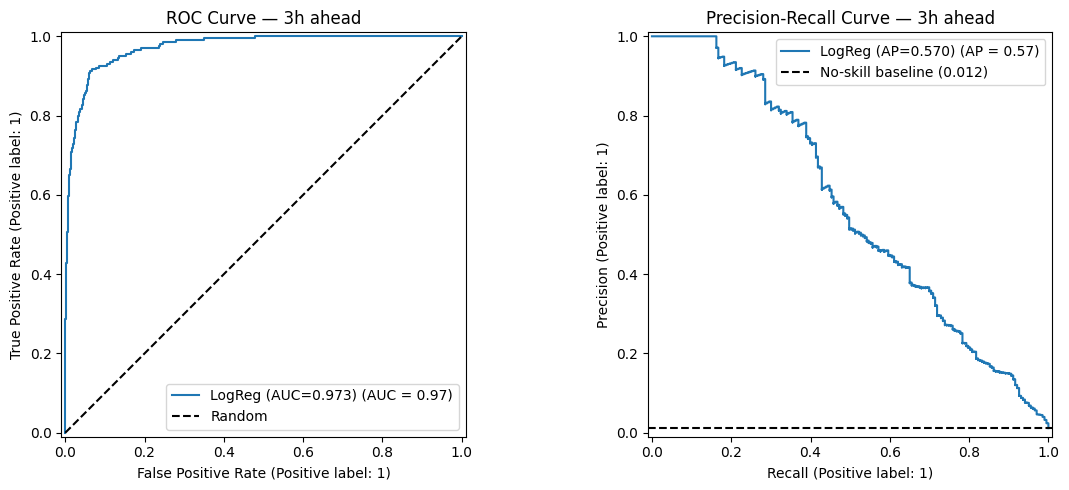

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, y_pred_prob,
    name=f"LogReg (AUC={roc_auc:.3f})", ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title(f"ROC Curve — {HORIZON}h ahead")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_prob,
    name=f"LogReg (AP={pr_auc:.3f})", ax=axes[1],
)
axes[1].axhline(y_test.mean(), color="k", linestyle="--",
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_title(f"Precision-Recall Curve — {HORIZON}h ahead")
axes[1].legend()

plt.tight_layout()
plt.show()

## Horizon = 12h

Same features, same temporal split, but now forecasting **12 hours ahead** instead of 3 — only the target column changes (`storm_12h`). Persistence weakens sharply at this horizon (its F1 drops from ~0.50 at 3h to ~0.21 at 12h), so this is where the model has the most room to add value over "assume it stays the same."

In [ ]:
HORIZON_12 = 12
y12 = df[f"storm_{HORIZON_12}h"]          # X is unchanged — features never include targets
y12_train, y12_test = y12.iloc[:split], y12.iloc[split:]

logrep_pipe_12 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
logrep_pipe_12.fit(X_train, y12_train)

y12_pred = logrep_pipe_12.predict(X_test)
y12_pred_prob = logrep_pipe_12.predict_proba(X_test)[:, 1]
roc_auc_12 = roc_auc_score(y12_test, y12_pred_prob)
pr_auc_12 = average_precision_score(y12_test, y12_pred_prob)

print(f"ROC-AUC : {roc_auc_12: .3f}")
print(f"PR-AUC : {pr_auc_12: .3f} (no-skill baseline = {y12_test.mean():.3f})")
print(classification_report(y12_test, y12_pred, target_names=['No storm', 'Storm']))
print(confusion_matrix(y12_test, y12_pred))

In [ ]:
# Persistence baseline vs model at 12h, plus the threshold sweep
persist_pred_12 = (X_test["ap_now"] >= STORM_THRESHOLD).astype(int)

print(f"=== {HORIZON_12}h ahead — base rate {y12_test.mean():.2%} ===\n")
print("Storm persistence baseline:")
print(f"  precision={precision_score(y12_test, persist_pred_12, zero_division=0):.3f}  "
      f"recall={recall_score(y12_test, persist_pred_12, zero_division=0):.3f}  "
      f"F1={f1_score(y12_test, persist_pred_12, zero_division=0):.3f}")

print("\nLogistic regression (threshold 0.50):")
print(f"  precision={precision_score(y12_test, y12_pred, zero_division=0):.3f}  "
      f"recall={recall_score(y12_test, y12_pred, zero_division=0):.3f}  "
      f"F1={f1_score(y12_test, y12_pred, zero_division=0):.3f}")
print(f"  ROC-AUC={roc_auc_12:.3f}  PR-AUC={pr_auc_12:.3f}")

rows_12 = []
for t in thresholds:
    yp = (y12_pred_prob >= t).astype(int)
    rows_12.append({
        "threshold": t,
        "accuracy": accuracy_score(y12_test, yp),
        "precision_storm": precision_score(y12_test, yp, zero_division=0),
        "recall_storm": recall_score(y12_test, yp, zero_division=0),
        "f1_storm": f1_score(y12_test, yp, zero_division=0),
        "predicted_storm_count": int(yp.sum()),
    })

pd.DataFrame(rows_12)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y12_test, y12_pred_prob,
    name=f"LogReg (AUC={roc_auc_12:.3f})", ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title(f"ROC Curve — {HORIZON_12}h ahead")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y12_test, y12_pred_prob,
    name=f"LogReg (AP={pr_auc_12:.3f})", ax=axes[1],
)
axes[1].axhline(y12_test.mean(), color="k", linestyle="--",
                label=f"No-skill baseline ({y12_test.mean():.3f})")
axes[1].set_title(f"Precision-Recall Curve — {HORIZON_12}h ahead")
axes[1].legend()

plt.tight_layout()
plt.show()